<a href="https://colab.research.google.com/github/bmehak/PCA_Gene_Expression/blob/main/PCA_Gene_Expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import gzip

expr = pd.read_csv("filtered.tsv.gz", sep="\t")

# Labels
labels = pd.read_csv("class.tsv", sep="\t", header=None)
labels.columns = ["class"]

print("Expression shape:", expr.shape)
print("Labels shape:", labels.shape)

Expression shape: (105, 16174)
Labels shape: (105, 1)


In [8]:
cols = pd.read_csv(
    "columns.tsv",
    sep="\t",
    comment="#",
    header=None
)

cols = cols[[0, 4]]
cols.columns = ["id", "gene"]

cols = cols.dropna()

cols.head()

,id,gene
0,ID,GeneSymbol
1,1,ACTB
2,2,ACTB
25,25,ACTB
26,26,RY1


In [9]:
cols = cols[cols["id"] != "ID"]
cols.head()

,id,gene
1,1,ACTB
2,2,ACTB
25,25,ACTB
26,26,RY1
27,27,RODH


In [10]:
xbp1 = cols[cols["gene"] == "XBP1"]
gata3 = cols[cols["gene"] == "GATA3"]

print(xbp1)
print(gata3)

        id  gene
4404  4404  XBP1
        id   gene
4359  4359  GATA3


In [15]:
print(type(expr.columns[0]))

<class 'str'>


In [16]:
print(expr.columns[:50])

Index(['    1', '    2', '    6', '   12', '   13', '   15', '   16', '   17',
       '   20', '   25', '   28', '   33', '   34', '   36', '   38', '   43',
       '   46', '   49', '   52', '   54', '   55', '   56', '   58', '   59',
       '   60', '   61', '   62', '   63', '   65', '   66', '   67', '   68',
       '   72', '   73', '   75', '   76', '   80', '   83', '   87', '   91',
       '   92', '   93', '   95', '  107', '  108', '  109', '  110', '  111',
       '  113', '  116'],
      dtype='object')


In [17]:
expr.columns = expr.columns.str.strip()

In [18]:
print(expr.columns[:50])

Index(['1', '2', '6', '12', '13', '15', '16', '17', '20', '25', '28', '33',
       '34', '36', '38', '43', '46', '49', '52', '54', '55', '56', '58', '59',
       '60', '61', '62', '63', '65', '66', '67', '68', '72', '73', '75', '76',
       '80', '83', '87', '91', '92', '93', '95', '107', '108', '109', '110',
       '111', '113', '116'],
      dtype='object')


In [19]:
df = pd.DataFrame({
    "XBP1": expr["4404"],
    "GATA3": expr["4359"],
    "class": labels["class"]
})

df.head()

,XBP1,GATA3,class
0,2.7836,2.2544,1
1,-0.3359,-0.7640,0
2,-1.0298,2.2355,0
3,2.6186,3.1732,1
4,2.5230,2.7418,1


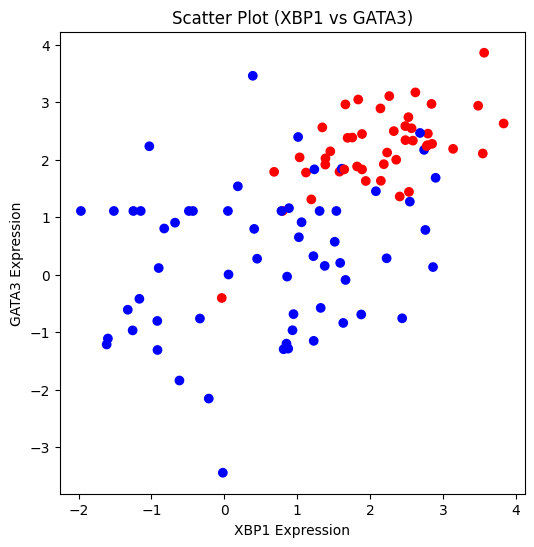

In [20]:
import matplotlib.pyplot as plt

colors = df["class"].map({1: "red", 0: "blue"})

plt.figure(figsize=(6,6))
plt.scatter(df["XBP1"], df["GATA3"], c=colors)

plt.xlabel("XBP1 Expression")
plt.ylabel("GATA3 Expression")
plt.title("Scatter Plot (XBP1 vs GATA3)")

plt.savefig("scatter_plot.png")
plt.show()

In [21]:
from sklearn.decomposition import PCA

X = df[["XBP1", "GATA3"]]

pca = PCA(n_components=1)
df["PC1"] = pca.fit_transform(X)

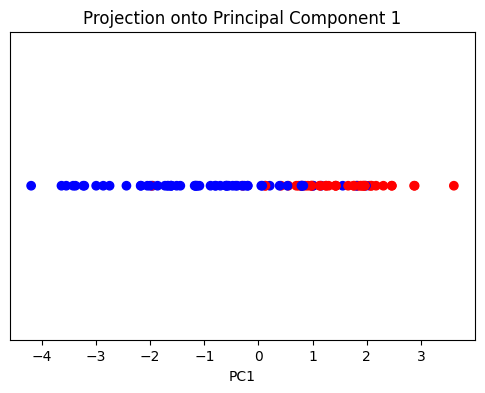

In [22]:
plt.figure(figsize=(6,4))

plt.scatter(df["PC1"], [0]*len(df), c=colors)

plt.xlabel("PC1")
plt.title("Projection onto Principal Component 1")

plt.yticks([])

plt.savefig("pca_plot.png")
plt.show()